In [1]:
import nibabel as nib
import numpy as np
from neuromaps.datasets import fetch_fslr, fetch_annotation
from nilearn.plotting.cm import _cmap_d as nilearn_cmaps

from arfcexp import surfvis

In [2]:
surfaces = fetch_fslr()
surf_lh_path, surf_rh_path = surfaces["inflated"]
sulc_lh_path, sulc_rh_path = surfaces["sulc"]
print(surf_lh_path)
print(sulc_lh_path)

/jet/home/clane2/neuromaps-data/atlases/fsLR/tpl-fsLR_den-32k_hemi-L_inflated.surf.gii
/jet/home/clane2/neuromaps-data/atlases/fsLR/tpl-fsLR_den-32k_hemi-L_desc-sulc_midthickness.shape.gii


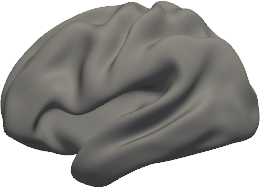

In [3]:
# Basic screenshot
plotter_lh = surfvis.Plotter(surf_lh_path, hemi="lh", width=256)
plotter_lh.screenshot()

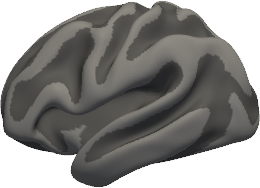

In [4]:
# Basic screenshot with sulc outline
plotter_lh = surfvis.Plotter(surf_lh_path, hemi="lh", sulc=sulc_lh_path, width=256)
plotter_lh.screenshot()

In [5]:
# Load margulies gradient for some overlay testing
grad_lh_path, grad_rh_path = fetch_annotation(
    source="margulies2016", desc="fcgradient01", space="fsLR", den="32k"
)

grad_lh = nib.load(grad_lh_path).darrays[0].data
grad_rh = nib.load(grad_rh_path).darrays[0].data

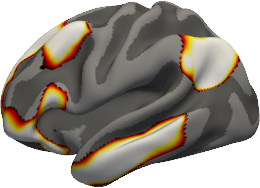

In [6]:
# Single overlay
plotter_lh = surfvis.Plotter(surf_lh_path, hemi="lh", sulc=sulc_lh_path, width=256)

plotter_lh.overlay(
    np.where(grad_lh > 4.0, grad_lh, np.nan),
    cmap=nilearn_cmaps["black_red"],
    vmin=4.0,
    vmax=6.0,
)

plotter_lh.screenshot()

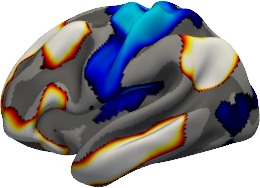

In [7]:
# Add another overlay
plotter_lh.overlay(
    np.where(grad_lh < -4.0, grad_lh, np.nan),
    cmap=nilearn_cmaps["black_blue_r"],
    vmin=-6.0,
    vmax=-4.0,
)

plotter_lh.screenshot(view="lateral")

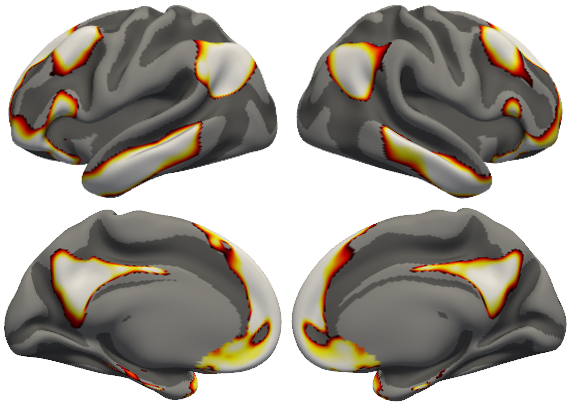

In [8]:
# Both hemi typical montage
plotter_lh = surfvis.Plotter(surf_lh_path, hemi="lh", sulc=sulc_lh_path, width=256)
plotter_rh = surfvis.Plotter(surf_rh_path, hemi="rh", sulc=sulc_rh_path, width=256)

plotter_lh.overlay(
    np.where(grad_lh > 4.0, grad_lh, np.nan),
    cmap=nilearn_cmaps["black_red"],
    vmin=4.0,
    vmax=6.0,
)

plotter_rh.overlay(
    np.where(grad_rh > 4.0, grad_rh, np.nan),
    cmap=nilearn_cmaps["black_red"],
    vmin=4.0,
    vmax=6.0,
)

images = [
    [plotter_lh.screenshot("lateral"), plotter_rh.screenshot("lateral")],
    [plotter_lh.screenshot("medial"), plotter_rh.screenshot("medial")],
]

# Nb, shareh/sharew makes all rows/cols same height/width
surfvis.montage(images, pad=4, shareh=True, sharew=True)

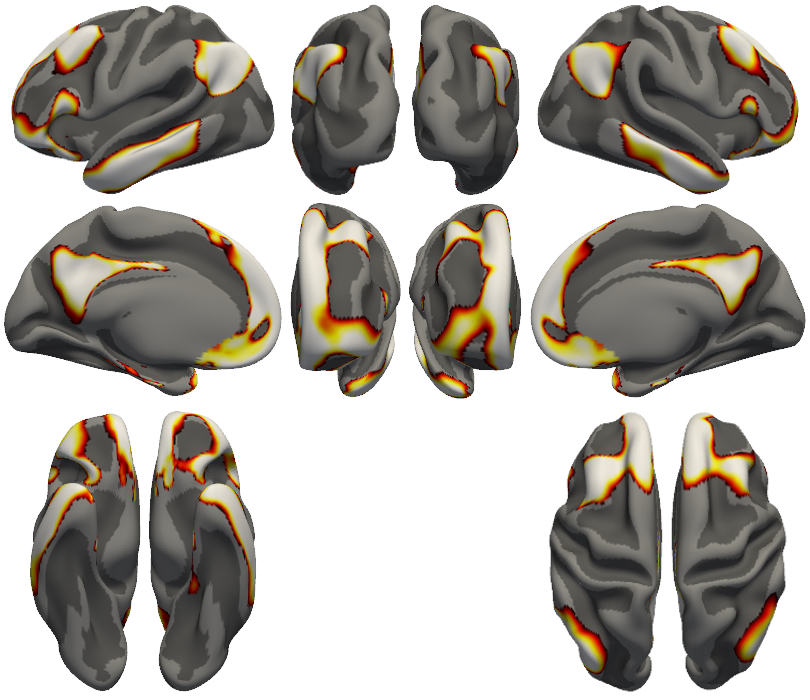

In [9]:
# Big complicated montage
plotter_lh = surfvis.Plotter(surf_lh_path, hemi="lh", sulc=sulc_lh_path, width=256)
plotter_rh = surfvis.Plotter(surf_rh_path, hemi="rh", sulc=sulc_rh_path, width=256)

plotter_lh.overlay(
    np.where(grad_lh > 4.0, grad_lh, np.nan),
    cmap=nilearn_cmaps["black_red"],
    vmin=4.0,
    vmax=6.0,
)

plotter_rh.overlay(
    np.where(grad_rh > 4.0, grad_rh, np.nan),
    cmap=nilearn_cmaps["black_red"],
    vmin=4.0,
    vmax=6.0,
)

images = [
    [
        plotter_lh.screenshot("lateral"),
        plotter_lh.screenshot("posterior"),
        plotter_rh.screenshot("posterior"),
        plotter_rh.screenshot("lateral"),
    ],
    [
        plotter_lh.screenshot("medial"),
        plotter_lh.screenshot("anterior"),
        plotter_rh.screenshot("anterior"),
        plotter_rh.screenshot("medial"),
    ],
    [
        surfvis.montage(
            [
                plotter_rh.screenshot(((0, 0, -500), (0, 0, 0), (0, 1, 0))),
                plotter_lh.screenshot(((0, 0, -500), (0, 0, 0), (0, 1, 0))),
            ],
            pad=4,
        ),
        None,
        None,
        surfvis.montage(
            [
                plotter_lh.screenshot(((0, 0, 500), (0, 0, 0), (0, 1, 0))),
                plotter_rh.screenshot(((0, 0, 500), (0, 0, 0), (0, 1, 0))),
            ],
            pad=4,
        ),
    ],
]

surfvis.montage(images, pad=4)

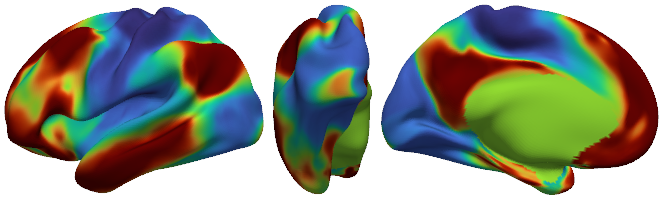

In [10]:
# Different view, different colormap, custom camera position.
# Looking at the weird occipita pole spot...
plotter_lh = surfvis.Plotter(surf_lh_path, hemi="lh", sulc=sulc_lh_path, width=256)

plotter_lh.overlay(
    grad_lh,
    cmap="turbo",
    vmin=-6.0,
    vmax=6.0,
)

surfvis.montage(
    [
        plotter_lh.screenshot("lateral"),
        plotter_lh.screenshot(((0, -500, -200), (0, 0, 0), (0, 0, 1))),
        plotter_lh.screenshot("medial"),
    ],
    pad=4,
)